# Ridge Analysis

## Imports

In [6]:
import sys
from pathlib import Path
import importlib

# Sørg for at code/ er på path
sys.path.append(str(Path("..").resolve()))

from Implementations import prepare_data
importlib.reload(prepare_data)

from Implementations.prepare_data import prepare_data





### Fetching data

In [7]:
import pandas as pd

df = pd.read_csv("../processed_player_value/nn_tabular_dataset.csv")

data = prepare_data(df, test_size=0.2, seed=42)
print(data["summary"])

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["ylog_train"].ravel()
y_test  = data["ylog_test"].ravel()

feature_cols = data["feature_cols"]
groups_full = data["groups_full"]


{'n_rows_total': 278558, 'n_rows_used': 275230, 'n_features': 15, 'test_size': 0.2, 'seed': 42, 'numeric_only': True, 'drop_na': True, 'standardize': True, 'player_overlap_train_test': 0}


### Ridge Baseline

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)  # baseline
ridge.fit(X_train, y_train)

pred_test = ridge.predict(X_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_test)

print(f"Ridge(alpha=1.0) | RMSE(log)={rmse:.4f} | R2(log)={r2:.4f}")


Ridge(alpha=1.0) | RMSE(log)=1.1122 | R2(log)=0.4546


### K-fold (group) cross validation

Best alpha (CV): 68.12920690579622 CV RMSE(log): 1.121175144828855


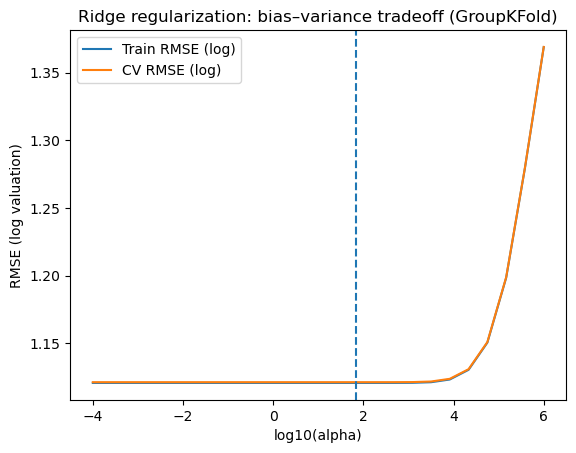

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

X_full = data["X_full"]
y_full = data["ylog_full"].ravel()
groups_full = data["groups_full"]

alphas = np.logspace(-4, 6, 25)  # juster gjerne antall punkter
gkf = GroupKFold(n_splits=5)

train_rmse = []
val_rmse = []

for a in alphas:
    rmse_tr = []
    rmse_va = []

    for tr_idx, va_idx in gkf.split(X_full, y_full, groups=groups_full):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=a))
        ])
        pipe.fit(X_full[tr_idx], y_full[tr_idx])

        pred_tr = pipe.predict(X_full[tr_idx])
        pred_va = pipe.predict(X_full[va_idx])

        rmse_tr.append(np.sqrt(mean_squared_error(y_full[tr_idx], pred_tr)))
        rmse_va.append(np.sqrt(mean_squared_error(y_full[va_idx], pred_va)))

    train_rmse.append(np.mean(rmse_tr))
    val_rmse.append(np.mean(rmse_va))

best_i = int(np.argmin(val_rmse))
best_alpha = alphas[best_i]
print("Best alpha (CV):", best_alpha, "CV RMSE(log):", val_rmse[best_i])

plt.figure()
plt.plot(np.log10(alphas), train_rmse, label="Train RMSE (log)")
plt.plot(np.log10(alphas), val_rmse, label="CV RMSE (log)")
plt.axvline(np.log10(best_alpha), linestyle="--")
plt.xlabel("log10(alpha)")
plt.ylabel("RMSE (log valuation)")
plt.title("Ridge regularization: bias–variance tradeoff (GroupKFold)")
plt.legend()
plt.show()


In [10]:
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train, y_train)

pred_test = ridge_best.predict(X_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_test)

print(f"Ridge(best alpha={best_alpha:.2e}) | RMSE(log)={rmse:.4f} | R2(log)={r2:.4f}")


Ridge(best alpha=6.81e+01) | RMSE(log)=1.1122 | R2(log)=0.4546


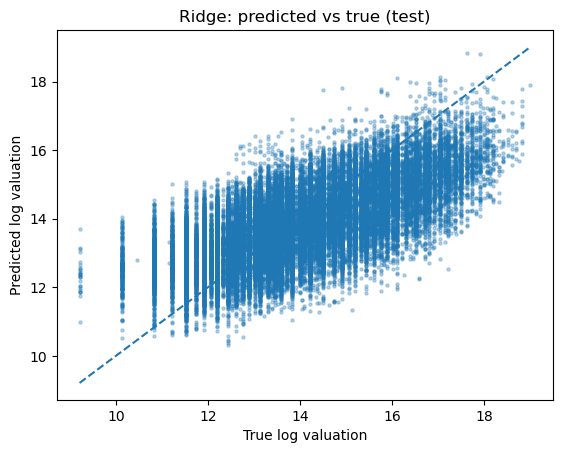

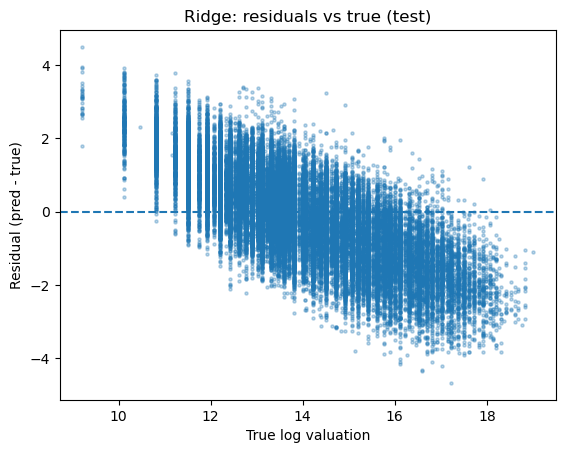

In [11]:
import matplotlib.pyplot as plt
import numpy as np

pred = ridge_best.predict(X_test)
residuals = pred - y_test

# Predicted vs true
plt.figure()
plt.scatter(y_test, pred, s=5, alpha=0.3)
mn = min(y_test.min(), pred.min())
mx = max(y_test.max(), pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True log valuation")
plt.ylabel("Predicted log valuation")
plt.title("Ridge: predicted vs true (test)")
plt.show()

# Residuals vs true
plt.figure()
plt.scatter(y_test, residuals, s=5, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("True log valuation")
plt.ylabel("Residual (pred - true)")
plt.title("Ridge: residuals vs true (test)")
plt.show()


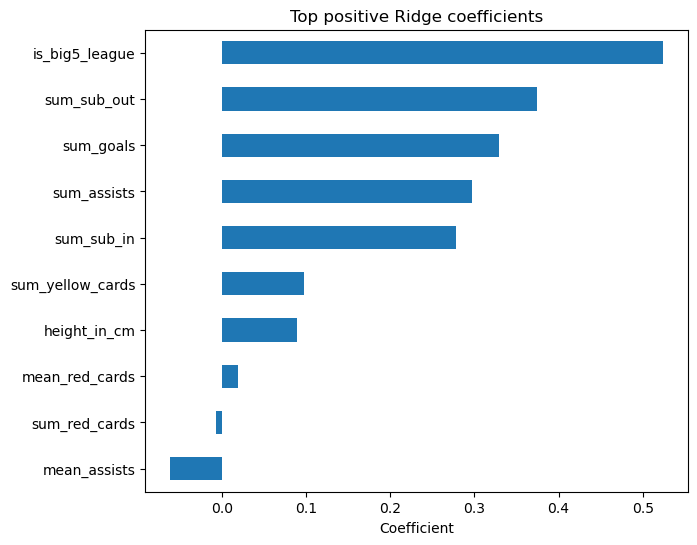

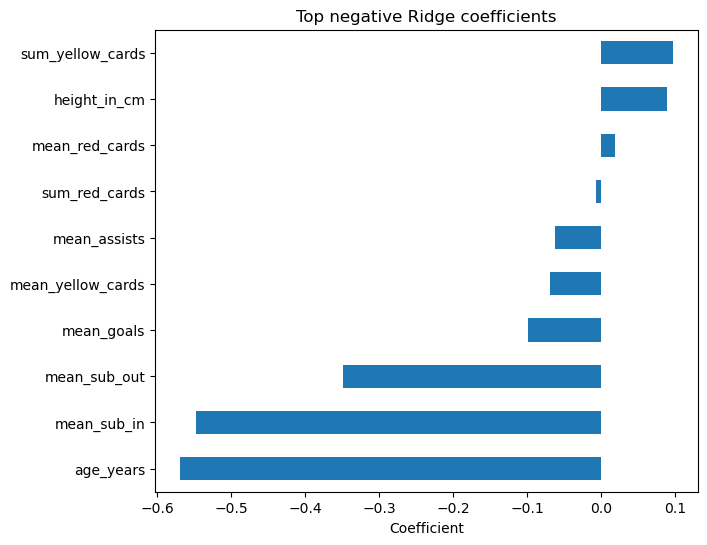

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

coef = pd.Series(ridge_best.coef_, index=feature_cols).sort_values()

plt.figure(figsize=(7, 6))
coef.tail(10).plot(kind="barh")
plt.title("Top positive Ridge coefficients")
plt.xlabel("Coefficient")
plt.show()

plt.figure(figsize=(7, 6))
coef.head(10).plot(kind="barh")
plt.title("Top negative Ridge coefficients")
plt.xlabel("Coefficient")
plt.show()

